In [360]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

from google.colab import drive

SEED = 42

In [337]:
uploaded = drive.mount("/content/drive")
#uploaded = drive.mount("/content/drive", force_remount=True)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [338]:
data = pd.read_csv("/content/drive/MyDrive/dataset/flood/flood.csv")
data.columns = ["tanggal",
                "suhu_min",
                "suhu_max",
                "suhu_avg",
                "kelembapan_avg",
                "curah_hujan",
                "durasi_matahari",
                "kecepatan_angin_max",
                "arah_angin_max",
                "kecepatan_angin_avg",
                "arah_angin_avg",
                "id_stasiun",
                "nama_stasiun",
                "nama_daerah",
                "banjir"
                ]

### EDA (Exploratory Data Analysis)
---

In [339]:
print("Data Shape:")
data.shape

Data Shape:


(6308, 15)

In [340]:
print("Data Head:")
data.head(10)

Data Head:


,tanggal,suhu_min,suhu_max,suhu_avg,kelembapan_avg,curah_hujan,durasi_matahari,kecepatan_angin_max,arah_angin_max,kecepatan_angin_avg,arah_angin_avg,id_stasiun,nama_stasiun,nama_daerah,banjir
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
5,2016-01-06,25.0,33.6,28.9,80.0,3.8,3.6,4.0,190.0,2.0,E,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
6,2016-01-07,25.2,35.6,30.0,78.0,NaN,7.6,4.0,60.0,2.0,E,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
7,2016-01-08,26.8,NaN,29.9,79.0,NaN,7.9,4.0,50.0,2.0,SE,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
8,2016-01-09,26.8,34.8,29.7,79.0,NaN,10.2,4.0,110.0,2.0,E,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
9,2016-01-10,25.4,34.6,29.2,80.0,NaN,8.2,3.0,80.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


In [341]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              6308 non-null   object 
 1   suhu_min             5996 non-null   float64
 2   suhu_max             6095 non-null   float64
 3   suhu_avg             6262 non-null   float64
 4   kelembapan_avg       6256 non-null   float64
 5   curah_hujan          3993 non-null   float64
 6   durasi_matahari      5049 non-null   float64
 7   kecepatan_angin_max  6286 non-null   float64
 8   arah_angin_max       6286 non-null   float64
 9   kecepatan_angin_avg  6215 non-null   float64
 10  arah_angin_avg       6207 non-null   object 
 11  id_stasiun           6308 non-null   int64  
 12  nama_stasiun         6308 non-null   object 
 13  nama_daerah          6308 non-null   object 
 14  banjir               6308 non-null   int64  
dtypes: float64(9), int64(2), ob

In [342]:
print("Data Describe:")
data.describe()

Data Describe:


,suhu_min,suhu_max,suhu_avg,kelembapan_avg,curah_hujan,durasi_matahari,kecepatan_angin_max,arah_angin_max,kecepatan_angin_avg,id_stasiun,banjir
count,5996.000000,6095.000000,6262.000000,6256.000000,3993.000000,5049.000000,6286.000000,6286.000000,6215.000000,6308.000000,6308.000000
mean,25.397598,32.577129,28.338135,76.903932,9.415502,5.008160,4.991887,193.518772,2.338214,96741.052949,0.075460
std,3.226555,5.571823,1.798969,9.719251,18.460319,2.788718,5.856961,109.211671,1.857624,5.239928,0.264153
min,2.400000,21.300000,23.700000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,96733.000000,0.000000
25%,24.400000,31.800000,27.700000,72.000000,0.000000,2.800000,4.000000,80.000000,1.000000,96733.000000,0.000000
50%,25.000000,32.600000,28.400000,77.000000,1.400000,5.400000,4.000000,230.000000,2.000000,96741.000000,0.000000
75%,26.000000,33.400000,29.100000,82.000000,10.500000,7.100000,5.000000,280.000000,3.000000,96745.000000,0.000000
max,246.000000,334.000000,141.600000,488.000000,277.500000,11.600000,185.000000,360.000000,82.000000,96747.000000,1.000000


In [343]:
print("Data Missing Value:")
print(data.isnull().sum().to_string())

Data Missing Value:
tanggal                   0
suhu_min                312
suhu_max                213
suhu_avg                 46
kelembapan_avg           52
curah_hujan            2315
durasi_matahari        1259
kecepatan_angin_max      22
arah_angin_max           22
kecepatan_angin_avg      93
arah_angin_avg          101
id_stasiun                0
nama_stasiun              0
nama_daerah               0
banjir                    0


In [344]:
print("Data Unique Value:")
print(data.nunique().to_string())

Data Unique Value:
tanggal                1814
suhu_min                 87
suhu_max                113
suhu_avg                 76
kelembapan_avg           50
curah_hujan             534
durasi_matahari         110
kecepatan_angin_max      31
arah_angin_max           57
kecepatan_angin_avg      14
arah_angin_avg            9
id_stasiun                4
nama_stasiun              4
nama_daerah               4
banjir                    2


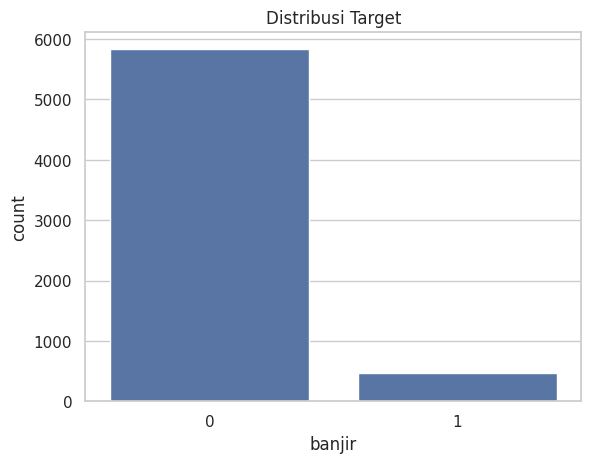

In [345]:
sns.countplot(x="banjir", data=data)
plt.title("Distribusi Target")
plt.show()

In [375]:
plot_config = pd.DataFrame(
    [
        {"column_name": "suhu_min", "is_histplot": True, "x_label": "Temperatur Minimum (°C)", "y_label": "Count"},
        {"column_name": "suhu_max", "is_histplot": True, "x_label": "Temperatur Maksimum (°C)", "y_label": "Count"},
        {"column_name": "suhu_avg", "is_histplot": True, "x_label": "Temperatur Rata-rata (°C)", "y_label": "Count"},
        {"column_name": "kelembapan_avg", "is_histplot": True, "x_label": "Kelembapan Rata-rata (%)", "y_label": "Count"},
        {"column_name": "curah_hujan", "is_histplot": True, "x_label": "Curah Hujan (mm)", "y_label": "Count"},
        {"column_name": "durasi_matahari", "is_histplot": True, "x_label": "Lama Penyinaran Matahari (jam)", "y_label": "Count"},
        {"column_name": "kecepatan_angin_max", "is_histplot": True, "x_label": "Kecepatan Angin Maksimum (m/s)", "y_label": "Count"},
        {"column_name": "arah_angin_max", "is_histplot": False, "x_label": "Arah Angin Saat Kecepatan Maksimum (°)", "y_label": "Count"},
        {"column_name": "kecepatan_angin_avg", "is_histplot": True, "x_label": "Kecepatan Angin Rata-rata (m/s)", "y_label": "Count"},
        {"column_name": "nama_daerah", "is_histplot": False, "x_label": "Nama Daerah", "y_label": "Count"},
        {"column_name": "arah_angin_avg", "is_histplot": False, "x_label": "Arah Angin Terbanyak", "y_label": "Count"}
    ]
)

In [347]:
data = data.dropna()

In [348]:
def derajat_ke_arah(deg):
    if pd.isna(deg):
        return np.nan
    deg = float(deg) % 360
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((deg + 22.5) // 45) % 8
    return directions[idx]

data["arah_angin_max"] = data["arah_angin_max"].apply(derajat_ke_arah)

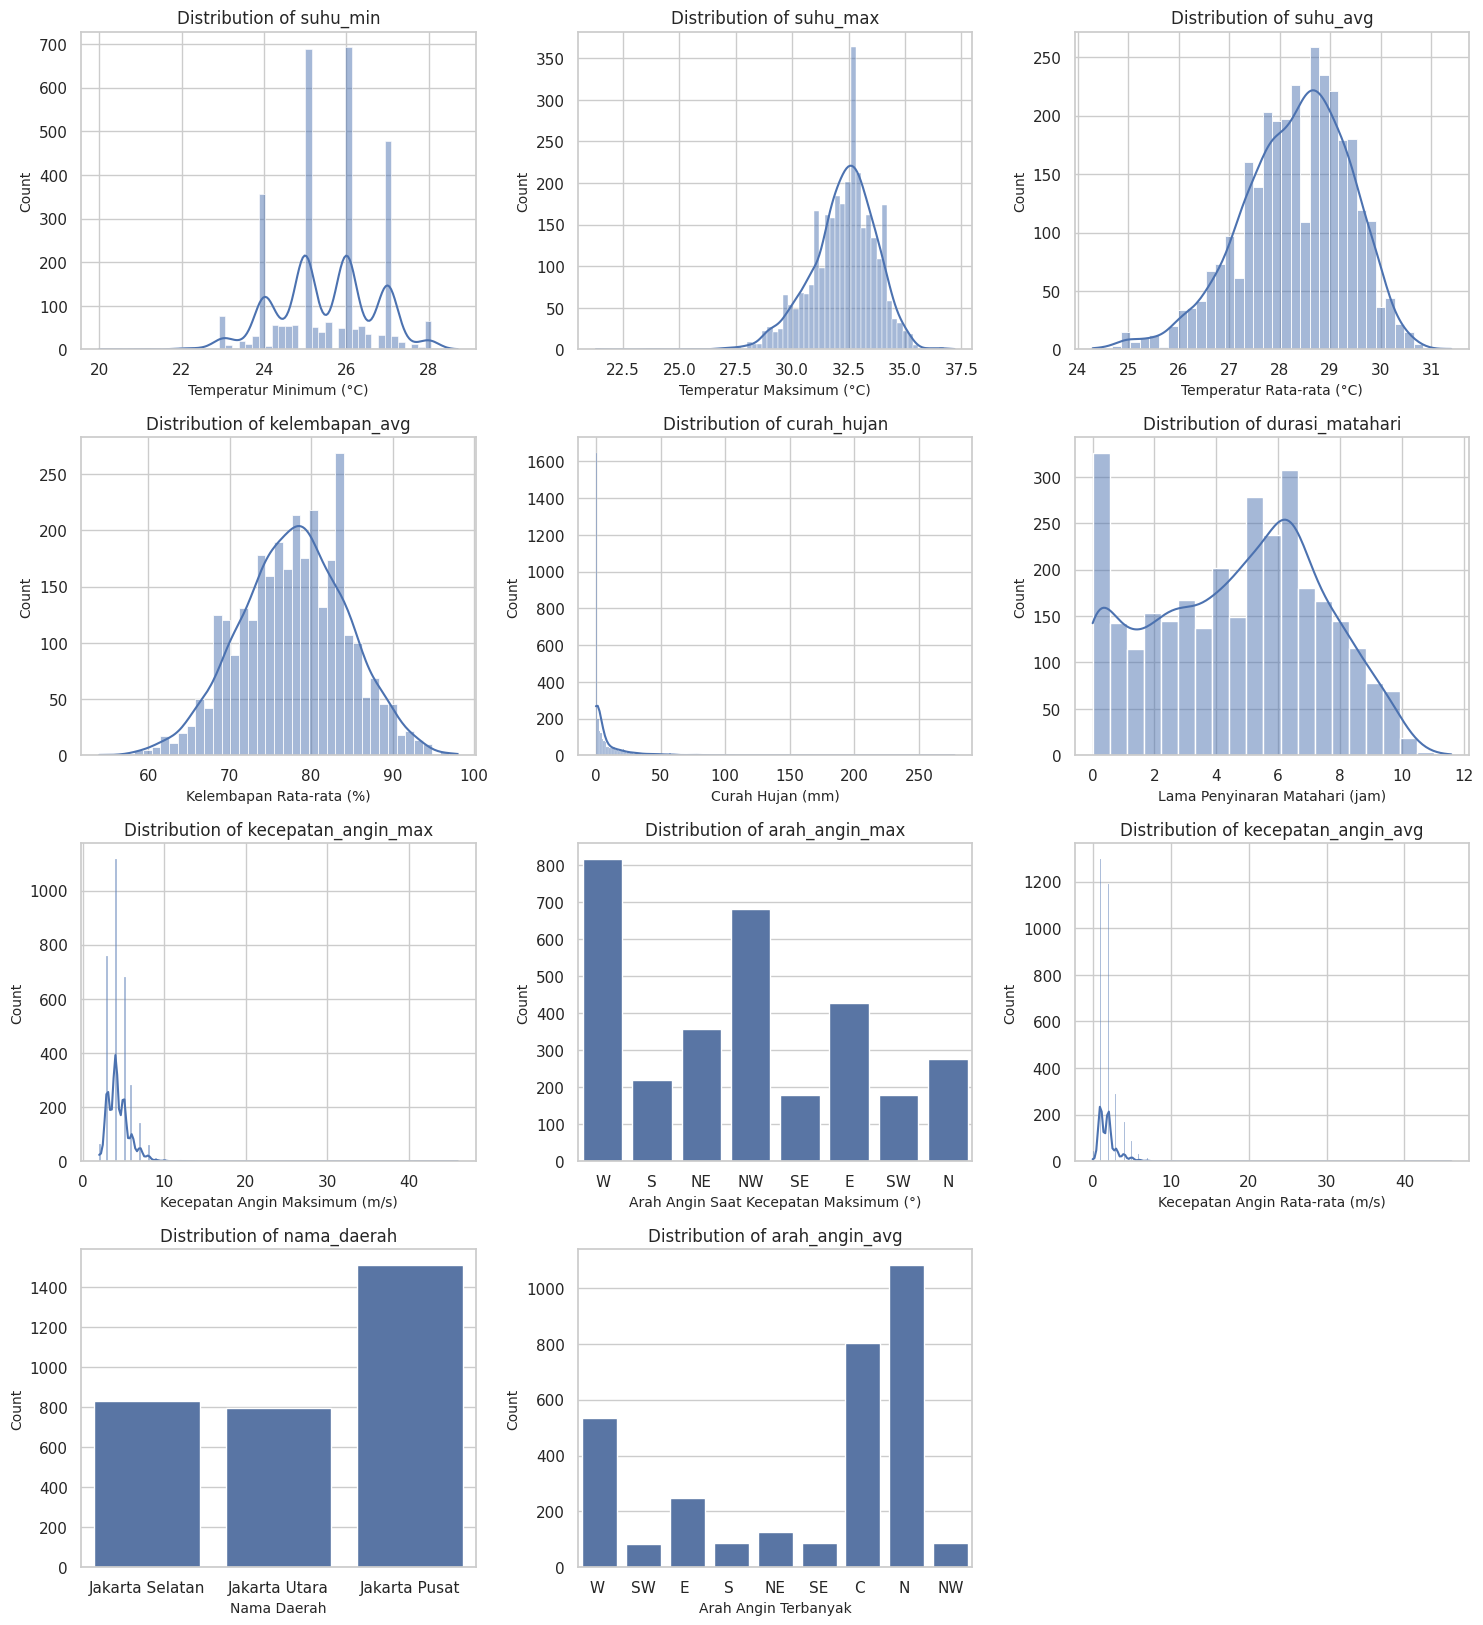

In [376]:
n_rows, n_cols = 5, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, row in plot_config.iterrows():
    col_name = row["column_name"]
    is_hist = row["is_histplot"]
    x_lbl = row["x_label"]
    y_lbl = row["y_label"]
    ax = axes[i]

    if is_hist:
        sns.histplot(data=data, x=col_name, ax=ax, kde=True)
    else:
        sns.countplot(data=data, x=col_name, ax=ax)

    ax.set_title(f"Distribution of {col_name}", fontsize=12)
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel(y_lbl, fontsize=10)

for j in range(len(plot_config), n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

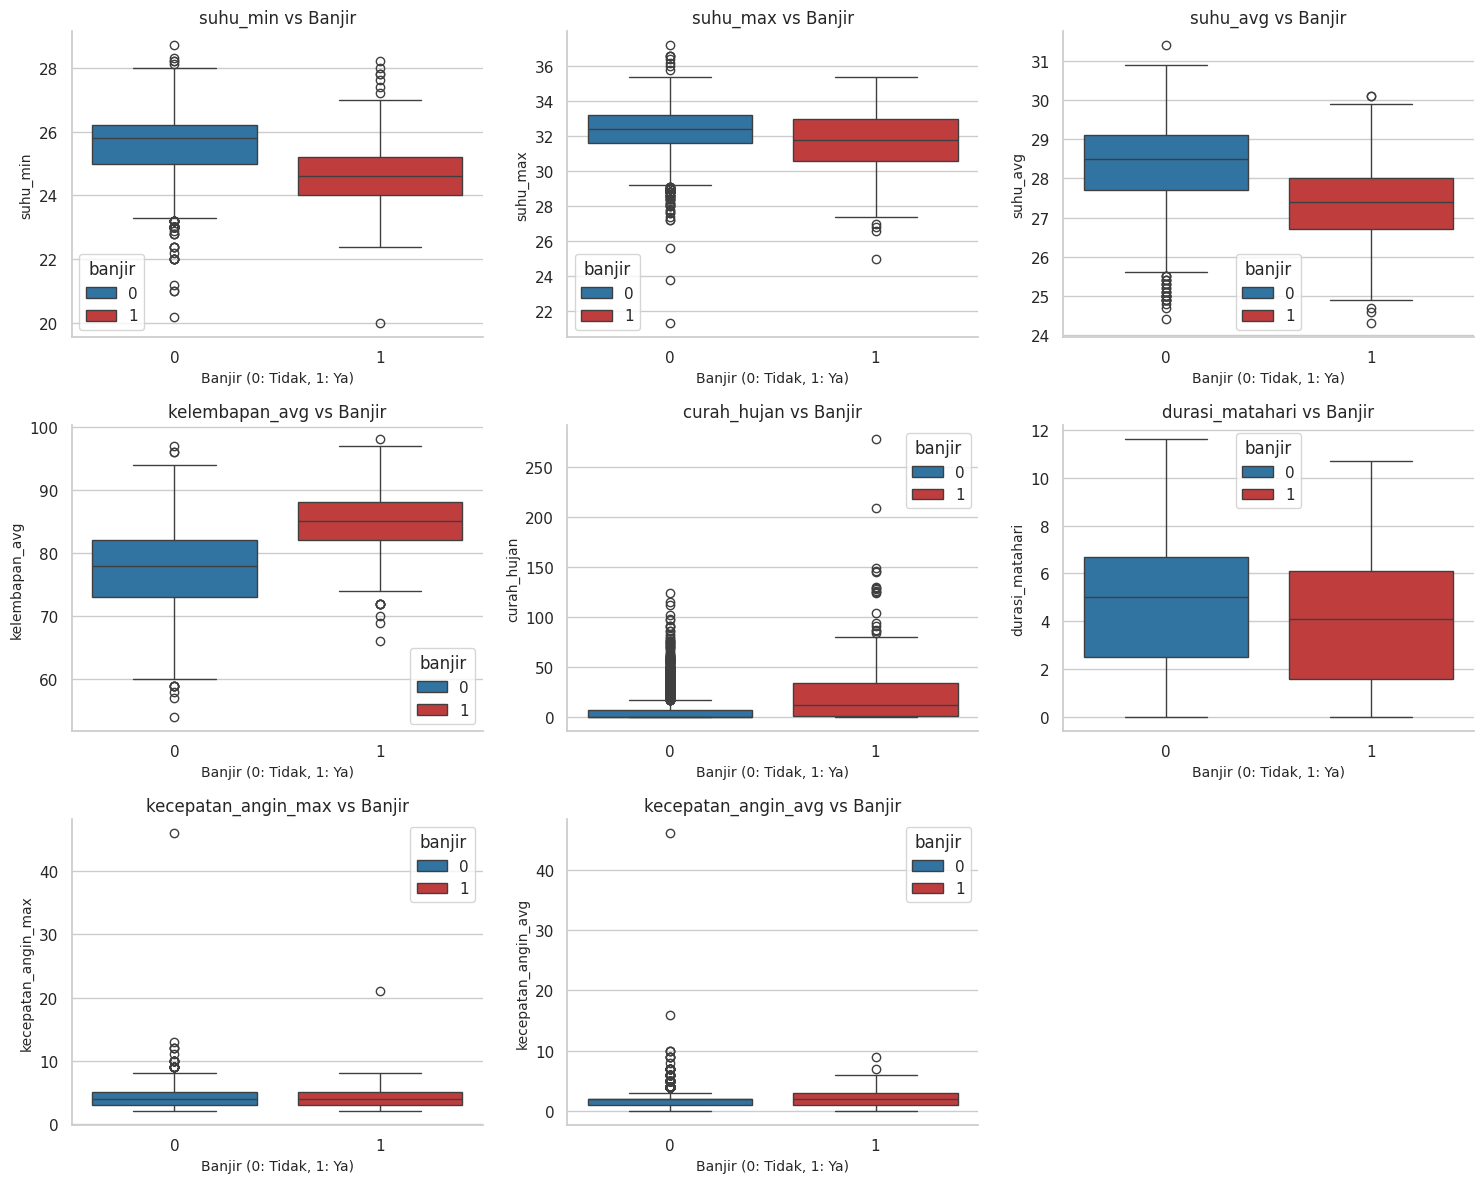

In [350]:
ratio_cols = plot_config[plot_config["is_histplot"]]["column_name"].tolist()

n_cols = 3
n_rows = (len(ratio_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

palette = {0: "#1f77b4", 1: "#d62728"}

for i, col_name in enumerate(ratio_cols):
    ax = axes[i]
    sns.boxplot(
        data=data,
        x="banjir",
        hue="banjir",
        y=col_name,
        ax=ax,
        palette=palette
    )

    ax.set_title(f"{col_name} vs Banjir", fontsize=12)
    ax.set_xlabel("Banjir (0: Tidak, 1: Ya)", fontsize=10)
    ax.set_ylabel(col_name, fontsize=10)
    sns.despine(ax=ax)

for j in range(len(ratio_cols), n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [351]:
data.head()

data.groupby("nama_daerah")["banjir"].value_counts()

nama_daerah      banjir
Jakarta Pusat    0         1494
                 1           17
Jakarta Selatan  0          671
                 1          158
Jakarta Utara    0          734
                 1           62
Name: count, dtype: int64

# Preprocessing

In [352]:
class DateEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy["tanggal"] = pd.to_datetime(data["tanggal"])
    data_copy["bulan"] = data_copy["tanggal"].dt.month
    data_copy["hari"] = data_copy["tanggal"].dt.day
    data_copy["tahun"] = data_copy["tanggal"].dt.year
    data_copy["hari_dalam_minggu"] = data_copy["tanggal"].dt.dayofweek
    data_copy = data_copy.drop(columns=["tanggal"], axis=1)
    return data_copy


class ArahAnginAvgEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.ohe = OneHotEncoder(sparse_output=False)
    self.ohe.fit(x[["arah_angin_avg"]])
    return self

  def transform(self, x):
    data_copy = x.copy()

    data_encoded = self.ohe.transform(data_copy[["arah_angin_avg"]])
    encoded_column_name = self.ohe.get_feature_names_out()
    data_encoded = pd.DataFrame(data_encoded, columns=encoded_column_name)

    data_copy = pd.concat([data_copy.reset_index(drop=True), data_encoded.reset_index(drop=True)], axis=1)
    data_copy = data_copy.drop(columns=["arah_angin_avg"], axis=1)

    return data_copy


class ArahAnginMaxEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.ohe = OneHotEncoder(sparse_output=False)
    self.ohe.fit(x[["arah_angin_max"]])
    return self


  def transform(self, x):
    data_copy = x.copy()

    data_encoded = self.ohe.transform(data_copy[["arah_angin_max"]])
    encoded_column_name = self.ohe.get_feature_names_out()
    data_encoded = pd.DataFrame(data_encoded, columns=encoded_column_name)

    data_copy = pd.concat([data_copy.reset_index(drop=True), data_encoded.reset_index(drop=True)], axis=1)
    data_copy = data_copy.drop(columns=["arah_angin_max"], axis=1)

    return data_copy


class NamaDaerahEncoder(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.ohe = OneHotEncoder(sparse_output=False)
    self.ohe.fit(x[["nama_daerah"]])
    return self


  def transform(self, x):
    data_copy = x.copy()

    data_encoded = self.ohe.transform(data_copy[["nama_daerah"]])
    encoded_column_name = self.ohe.get_feature_names_out()
    data_encoded = pd.DataFrame(data_encoded, columns=encoded_column_name)

    data_copy = pd.concat([data_copy.reset_index(drop=True), data_encoded.reset_index(drop=True)], axis=1)
    data_copy = data_copy.drop(columns=["nama_daerah"], axis=1)

    return data_copy


class FeatureDropper(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy = data_copy.drop(columns=["id_stasiun", "nama_stasiun"], axis=1)
    return data_copy

In [353]:
preprocessor = Pipeline([("date_encoder", DateEncoder()),
                        ("arah_angin_avg_encoder", ArahAnginAvgEncoder()),
                        ("arah_angin_max_encoder", ArahAnginMaxEncoder()),
                        ("nama_daerah_encoder", NamaDaerahEncoder()),
                        ("feature_dropper", FeatureDropper())])

preprocessed_data = preprocessor.fit_transform(data)
preprocessed_data.head()

,suhu_min,suhu_max,suhu_avg,kelembapan_avg,curah_hujan,durasi_matahari,kecepatan_angin_max,kecepatan_angin_avg,banjir,bulan,hari,tahun,hari_dalam_minggu,arah_angin_avg_C,arah_angin_avg_E,arah_angin_avg_N,arah_angin_avg_NE,arah_angin_avg_NW,arah_angin_avg_S,arah_angin_avg_SE,arah_angin_avg_SW,arah_angin_avg_W,arah_angin_max_E,arah_angin_max_N,arah_angin_max_NE,arah_angin_max_NW,arah_angin_max_S,arah_angin_max_SE,arah_angin_max_SW,arah_angin_max_W,nama_daerah_Jakarta Pusat,nama_daerah_Jakarta Selatan,nama_daerah_Jakarta Utara
0,25.6,33.2,27.0,88.0,1.6,8.7,4.0,2.0,1,1,2,2016,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,24.4,34.9,28.1,80.0,33.8,5.4,4.0,2.0,1,1,3,2016,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,25.0,33.6,28.9,80.0,3.8,3.6,4.0,2.0,0,1,6,2016,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,26.2,31.2,26.0,93.0,11.5,5.7,3.0,1.0,1,1,12,2016,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,24.8,33.3,26.3,92.0,36.3,0.9,3.0,1.0,0,1,13,2016,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [361]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_data, test_data = None, None

for train_idx, test_idx in split.split(preprocessed_data, preprocessed_data["banjir"]):
  train_data = preprocessed_data.iloc[train_idx]
  test_data = preprocessed_data.iloc[test_idx]

In [362]:
x_train_raw = train_data.drop(columns=["banjir"], axis=1)
y_train_raw = train_data["banjir"]

smote = SMOTE(random_state=SEED)
x_train_res, y_train_res = smote.fit_resample(x_train_raw, y_train_raw)

train_data = pd.concat([x_train_res, y_train_res], axis=1)

print("Distribusi label setelah SMOTE:")
print(train_data["banjir"].value_counts())

Distribusi kelas setelah SMOTE:
banjir
0    2318
1    2318
Name: count, dtype: int64


In [363]:
x_knn_train, y_knn_train = train_data.drop(columns=["banjir"], axis=1), train_data["banjir"]
x_knn_test, y_knn_test = test_data.drop(columns=["banjir"], axis=1), test_data["banjir"]

x_log_reg_train, y_log_reg_train = train_data.drop(columns=["banjir"], axis=1), train_data["banjir"]
x_log_reg_test, y_log_reg_test = test_data.drop(columns=["banjir"], axis=1), test_data["banjir"]

x_dec_tree_train, y_dec_tree_train = train_data.drop(columns=["banjir"], axis=1), train_data["banjir"]
x_dec_tree_test, y_dec_tree_test = test_data.drop(columns=["banjir"], axis=1), test_data["banjir"]

In [364]:
knn_scaler = StandardScaler()
x_knn_train = knn_scaler.fit_transform(x_knn_train)
x_knn_test = knn_scaler.transform(x_knn_test)

log_reg_scaler = StandardScaler()
x_log_reg_train = log_reg_scaler.fit_transform(x_log_reg_train)
x_log_reg_test = log_reg_scaler.transform(x_log_reg_test)

### TRAINING MODEL
---

In [365]:
models = {
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "x_train": x_knn_train,
        "y_train": y_knn_train,
        "x_test": x_knn_test,
        "y_test": y_knn_test
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=SEED),
        "x_train": x_log_reg_train,
        "y_train": y_log_reg_train,
        "x_test": x_log_reg_test,
        "y_test": y_log_reg_test
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=SEED),
        "x_train": x_dec_tree_train,
        "y_train": y_dec_tree_train,
        "x_test": x_dec_tree_test,
        "y_test": y_dec_tree_test
    }
}

param_grids = {
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"]
    },
    "Decision Tree": {
        "max_depth": [None, 3, 5, 7, 10],
        "criterion": ["gini", "entropy"],
        "min_samples_split": [2, 5, 10]
    }
}

In [366]:
results = []
best_models = {}

for name, config in models.items():
    print(f"Training {name}...")

    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=param_grids[name],
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    grid_search.fit(config["x_train"], config["y_train"])

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(config["x_test"])

    acc = accuracy_score(config["y_test"], y_pred)
    prec = precision_score(config["y_test"], y_pred, average="weighted", zero_division=0)
    rec = recall_score(config["y_test"], y_pred, average="weighted", zero_division=0)
    f1 = f1_score(config["y_test"], y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Best Parameters": grid_search.best_params_,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
    })

df_results = pd.DataFrame(results)

Training K-Nearest Neighbors...
Training Logistic Regression...
Training Decision Tree...


In [367]:
print("\n========= HASIL EVALUASI MENGGUNAKAN GRIDSEARCHCV =========")
df_results.sort_values(by="F1-Score", ascending=False)


========= HASIL EVALUASI MENGGUNAKAN GRIDSEARCHCV =========


,Model,Best Parameters,Accuracy,Precision,Recall,F1-Score
2,Decision Tree,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.885350,0.885350,0.885350,0.885350
0,K-Nearest Neighbors,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.855096,0.886891,0.855096,0.869539
1,Logistic Regression,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.792994,0.931767,0.792994,0.838905


### EVAL
---

============================ EVAL ============================


,Model,Accuracy,Precision,Recall,F1-Score
2,Decision Tree,0.885350,0.885350,0.885350,0.885350
0,K-Nearest Neighbors,0.855096,0.886891,0.855096,0.869539
1,Logistic Regression,0.792994,0.931767,0.792994,0.838905


TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

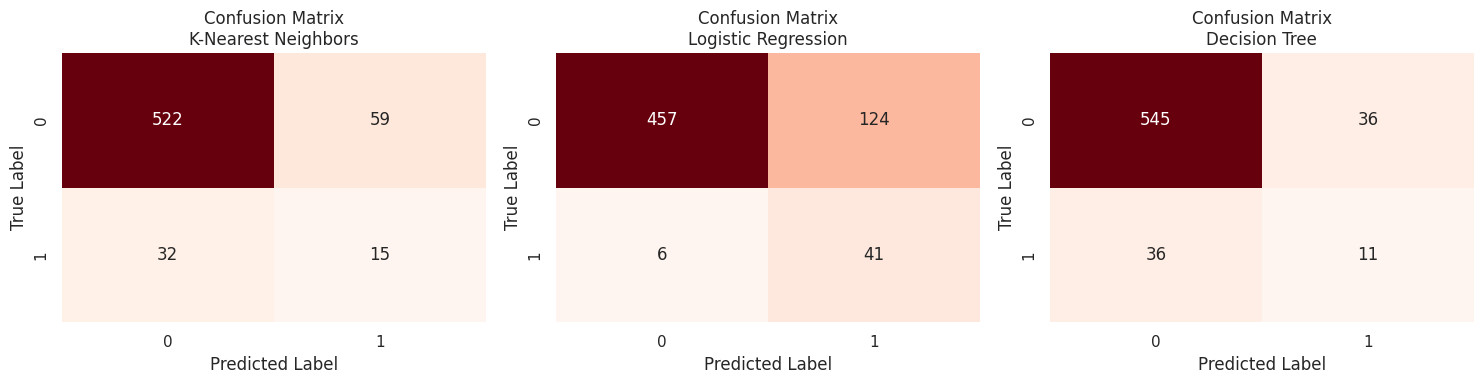

In [374]:
metrics_list = []
cm_dict = {}

for name, model in best_models.items():
    x_test_curr = models[name]["x_test"]
    y_test_curr = models[name]["y_test"]

    y_pred = model.predict(x_test_curr)

    acc = accuracy_score(y_test_curr, y_pred)
    prec = precision_score(y_test_curr, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test_curr, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_curr, y_pred, average="weighted", zero_division=0)

    metrics_list.append({
                        "Model": name,
                        "Accuracy": acc,
                        "Precision": prec,
                        "Recall": rec,
                        "F1-Score": f1})
    cm_dict[name] = confusion_matrix(y_test_curr, y_pred)

df_metrics = pd.DataFrame(metrics_list)
print("============================ EVAL ============================")
display(df_metrics.sort_values(by="F1-Score", ascending=False))
print("==============================================================\n\n")

num_models = len(best_models)
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 4))

labels = np.unique(y_knn_test)

for ax, (name, cm) in zip(axes, cm_dict.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=False,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels)

    ax.set_title(f"Confusion Matrix\n{name}", fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

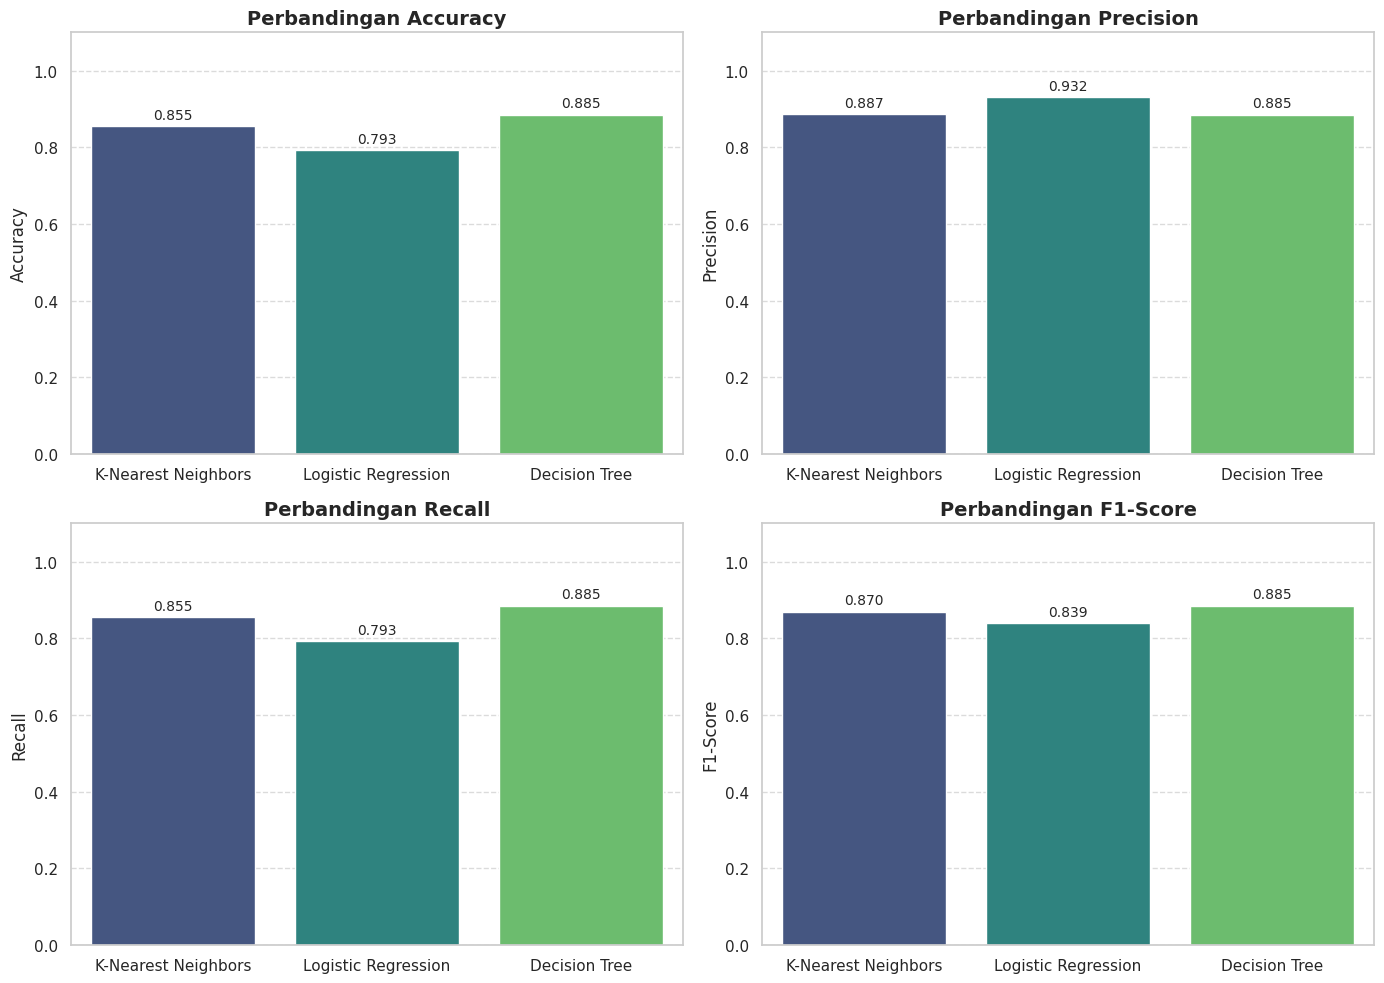

In [379]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_results,
        x="Model",
        y=metric,
        ax=axes[i],
        palette="viridis",
        hue="Model",
        legend=False,
    )

    axes[i].set_title(f"Perbandingan {metric}", fontsize=14, fontweight="bold")
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.savefig("perbandingan_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

### DEMO
---